#Section 1: Dataset

The bcc news dataset has 2225 articles that have been published by the bbc from 2004-2005. Each of these articles is labeled under one of these 5 categories business, entertainment, politics, sport and tech. This dataset is split into two columns one for the articles which is text and one for the categories which is also text. This dataset can be used for text classification in this case multi class text classification. The task I will be going in this coursework is text classification. Where the goal is to successfully predict the category label of an article. Due to this task being text classification I believe an NLP system would be good for this task. My reason for believing this is that an NLP system is very good at understanding and interpreting text due to be designed with this in mind and it can work well with big datasets.

In [1]:
import numpy as np
import io
from google.colab import files
import pandas as pd
np.random.seed(1337)
uploaded = files.upload()
dataset = io.BytesIO(uploaded['bbc-text.csv'])
textdataset = np.loadtxt(dataset,dtype=str,delimiter=",")
df = pd.DataFrame(textdataset)
print(textdataset)

Saving bbc-text.csv to bbc-text.csv
[['category' 'text']
 ['tech'
  'tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows

In [2]:
print(df) #shows dataset

                  0                                                  1
0          category                                               text
1              tech  tv future in the hands of viewers with home th...
2          business  worldcom boss  left books alone  former worldc...
3             sport  tigers wary of farrell  gamble  leicester say ...
4             sport  yeading face newcastle in fa cup premiership s...
...             ...                                                ...
2221       business  cars pull down us retail figures us retail sal...
2222       politics  kilroy unveils immigration policy ex-chatshow ...
2223  entertainment  rem announce new glasgow concert us band rem h...
2224       politics  how political squabbles snowball it s become c...
2225          sport  souness delight at euro progress boss graeme s...

[2226 rows x 2 columns]


In [3]:
df.shape # tells me how many rows and columns there are

(2226, 2)

In [4]:
df.duplicated() #check if there is any duplicates in my dataset

,0
0,False
1,False
2,False
3,False
4,False
...,...
2221,False
2222,False
2223,False
2224,False


In [5]:
df.describe() # describes the maximum and mean values dataset

,0,1
count,2226,2226
unique,6,2127
top,sport,boothroyd calls for lords speaker betty boothr...
freq,511,2


In [6]:
df.head()#show first five


,0,1
0,category,text
1,tech,tv future in the hands of viewers with home th...
2,business,worldcom boss left books alone former worldc...
3,sport,tigers wary of farrell gamble leicester say ...
4,sport,yeading face newcastle in fa cup premiership s...


In [7]:
df.tail() #show last five

,0,1
2221,business,cars pull down us retail figures us retail sal...
2222,politics,kilroy unveils immigration policy ex-chatshow ...
2223,entertainment,rem announce new glasgow concert us band rem h...
2224,politics,how political squabbles snowball it s become c...
2225,sport,souness delight at euro progress boss graeme s...


In [8]:
y , x = textdataset.T # split data into x and y
x= np.delete(x,0) # delete first element as it a label for text and not data
y= np.delete(y,0)  # delete first element as it a label for category and not data
print(x[0:2]) #show articles

['tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-in to hig

In [9]:
print(y[0:5]) # show categories

['tech' 'business' 'sport' 'sport' 'entertainment']


In [10]:
#import tokenizer and stopwords

import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [11]:
from sklearn.base import TransformerMixin
from sklearn.base import BaseEstimator
class preProcess(BaseEstimator,TransformerMixin):

  def __init__(self):
    return None

  def fit(self,X,y=None):
    return self


  def transform(self, X,y = None):
    prep_text=[] #array for preptext
    for x in X: #for each sentance in the text column tokenize them
      token_text = word_tokenize(x)
      #print(token_text)
      normalise_text = [token.lower() for token in token_text if token.isalpha()]
      #print(normalise_text)

      swr_text = [token for token in normalise_text if token not in stopwords.words('english')]



      stemmer = SnowballStemmer('english')

      prep_text +=[[stemmer.stem(word)for word in swr_text]]
      #print(prep_text)

    prep_sentances =[" ".join(sentance)for sentance in prep_text]

    return prep_sentances


In [12]:
prep_x = preProcess().transform(x) # test my pre processing function
print(prep_x[0:2])

['tv futur hand viewer home theatr system plasma tvs digit video record move live room way peopl watch tv radic differ five year time accord expert panel gather annual consum electron show las vega discuss new technolog impact one favourit pastim us lead trend programm content deliv viewer via home network cabl satellit telecom compani broadband servic provid front room portabl devic one technolog ces digit person video record dvr pvr box like us tivo uk system allow peopl record store play paus forward wind tv programm want essenti technolog allow much personalis tv also tv set big busi japan us slower take europ lack program peopl forward wind advert also forget abid network channel schedul put togeth entertain us network cabl satellit compani worri mean term advertis revenu well brand ident viewer loyalti channel although us lead technolog moment also concern rais europ particular grow uptak servic like happen today see nine month year time uk adam hume bbc broadcast futurologist to

#Section 2: Representation Learning


For my Representation learning I’m using TfidfVectorizer to convert my text into a numerical vector. Tfidt stands for Term-frequency (TF) and inverse document frequency(IDF). TF measures how frequent a word is for 1 document  and counts it. IDF measures how many times the word appears in every document it then does log number of times it appears / by number of documents. Tf and IDF are then multiplied together to give the numerical vector that represents that word. I chose this in my coursework because I believe that the way it calculates word importance will make it so that unique words that only appear in certain categories have a higher score than common words that appear in every article so it should make it easier to sort them.



In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorise = TfidfVectorizer(max_features = 500)
test_vectorise = vectorise.fit_transform(prep_x)
print(test_vectorise)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 141031 stored elements and shape (2225, 500)>
  Coords	Values
  (0, 464)	0.5301495263957775
  (0, 183)	0.08015189721245951
  (0, 200)	0.08521143142072012
  (0, 209)	0.06989684998984942
  (0, 436)	0.08220095532430301
  (0, 127)	0.09268830639291627
  (0, 474)	0.09425444653181107
  (0, 375)	0.2191591985242035
  (0, 295)	0.03374152284960301
  (0, 258)	0.0393906387971522
  (0, 481)	0.060944965781362256
  (0, 329)	0.18462477251105155
  (0, 126)	0.04125366251406919
  (0, 172)	0.03610503566935264
  (0, 497)	0.039591503365833655
  (0, 451)	0.04972873408943538
  (0, 2)	0.03752807231633999
  (0, 98)	0.09050298094215808
  (0, 408)	0.09434794033999572
  (0, 308)	0.07124827753382842
  (0, 443)	0.20835604737097266
  (0, 318)	0.09148629073306021
  (0, 469)	0.18081532743403084
  (0, 244)	0.07623950815832019
  (0, 355)	0.16732525820925145
  :	:
  (2224, 85)	0.10811314674621787
  (2224, 496)	0.10192040918934238
  (2224, 447)	0.2417981975635797

In [ ]:
test_vectorise.shape

(2225, 500)

#Section 3: Algorithms

### Algorithm 1: k-Nearest Neighbour

The First algorithm I'm using for this course-work is k-Nearest Neighbour, k-Nearest Neighbour is a similarity based machine learning algorithm which can be used for classification and regression tasks. The way it works is it compares the data from the test data and the training points. It then calculates the distance from test data and the training points (i.e how similar they are).The method that is used to calculate the distance (called the Euclidean Distance) is Pythagoras's theorem (the square root of (X2-X1)^2+(Y2 -Y1)^2). Then it finds the nearest K neighbour based on how close the distance is. The K is how many neighbours the point has to compare against so if there is more of a certain labels it will be the more frequent label. After it has done this it will assign which label the data belongs to or in the case of this coursework which category the article belongs to. I Think this will be good algorithm to use because articles about certain categories are more likely to have similar words that could help identify which category the article belongs to.

###Algorithm 2: Descision Tree

The second algorithm I’m using for my coursework is Decision Tree. Decision Tree is a conventional machine learning algorithm and can be used for both regression and classification tasks. The way a decision tree works is that it creates a tree structure/diagram from the dataset. The starting point is the root node which is the whole dataset. It will compare the root node to the decision nodes and will pick the one that splits the data the best. It picks the best split by using a loss evaluation function. These evaluation functions are called Gini Impurity and Entropy. Gini impurity measures how often a random element would be given the wrong label according to the distribution of the labels. Entropy measures the chaos / disorder of the nodes in the tree. After going through multiple decision nodes it will eventually reach a terminal node( a leaf node) which will then be the label in my case for this coursework the category the article belongs to. I think this will be an interesting algorithm to use because it’s different then k-Nearest Neighbour in the way it predicts what category an article should be. I also used it in another coursework and wanted to see how well it would work for a text classification task.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier



Knn_clf = Pipeline([
  ('prep', preProcess()),
  ('rep',vectorise),
  ('mod', KNeighborsClassifier(n_neighbors=5)),
  ])

tree_clf = Pipeline([
  ('prep', preProcess()),
  ('rep',vectorise),
  ('mod', DecisionTreeClassifier(random_state=42)),
  ])

Knn_score = []
Dtree_score = []

Knn_precision = []
Dtree_precision = []

Knn_recall = []
Dtree_recall = []

Knn_f1 = []
Dtree_f1 =[]



kf = StratifiedKFold(n_splits=5)
for train, test in kf.split(x,y):

  x_train, x_test, y_train, y_test = x[train], x[test], y[train], y[test]

  Knn_clf.fit(x_train, y_train)
  predictions = Knn_clf.predict(x_test)
  knn_acc = accuracy_score(predictions, y_test)
  Knn_score.append(knn_acc)

  knn_prec = precision_score(predictions, y_test,average='weighted')
  Knn_precision.append(knn_prec)

  knn_rec = recall_score(predictions, y_test,average='weighted')
  Knn_recall.append(knn_rec)

  knn_f = f1_score(predictions, y_test,average='weighted')
  Knn_f1.append(knn_f)

  tree_clf.fit(x_train, y_train)
  predictions = tree_clf.predict(x_test)
  tree_acc = accuracy_score(predictions, y_test)
  Dtree_score.append(tree_acc)

  Dtree_prec = precision_score(predictions, y_test,average='weighted')
  Dtree_precision.append(Dtree_prec)

  Dtree_rec = recall_score(predictions, y_test,average='weighted')
  Dtree_recall.append(Dtree_rec)

  Dtree_f = f1_score(predictions, y_test,average='weighted')
  Dtree_f1.append(Dtree_f)

print("Knn Accuracy:", np.mean(Knn_score),"Decision Tree Accuracy:", np.mean(Dtree_score))
print("Knn Precision", np.mean(Knn_precision),"Decision Tree Precision:", np.mean(Dtree_precision))
print("Knn recall", np.mean(Knn_recall),"Decision Tree recall:", np.mean(Dtree_recall))
print("Knn F1 Score", np.mean(Knn_f1),"Decision Tree F1 Score:", np.mean(Dtree_f1))
#It took about 12 minutes to run

Knn Accuracy: 0.9191011235955056 Decision Tree Accuracy: 0.8287640449438202
Knn Precision 0.919666040058587 Decision Tree Precision: 0.8312112654132706
Knn recall 0.9191011235955056 Decision Tree recall: 0.8287640449438202
Knn F1 Score 0.9187645242843949 Decision Tree F1 Score: 0.8289122450095222


#Section 4: Evaluation

[Text(1, 0, 'knn'), Text(2, 0, 'DTree')]

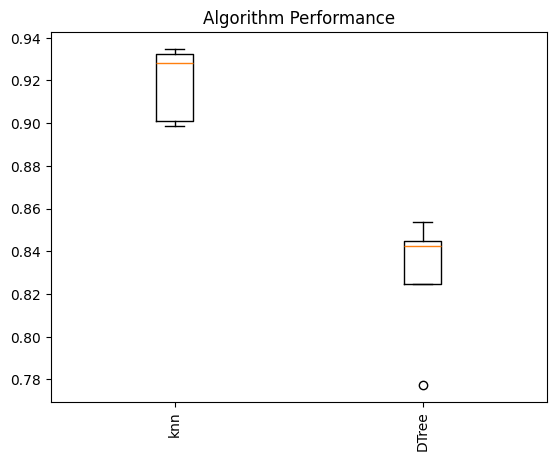

In [15]:
import matplotlib as plt

model_comp = []
model_comp.append(Knn_score)
model_comp.append(Dtree_score)

fig, ax2 = plt.pyplot.subplots()
ax2.set_title('Algorithm Performance')
ax2.boxplot(model_comp)
ax2.set_xticklabels(['knn', 'DTree'], rotation='vertical')

[Text(1, 0, 'knn'), Text(2, 0, 'DTree')]

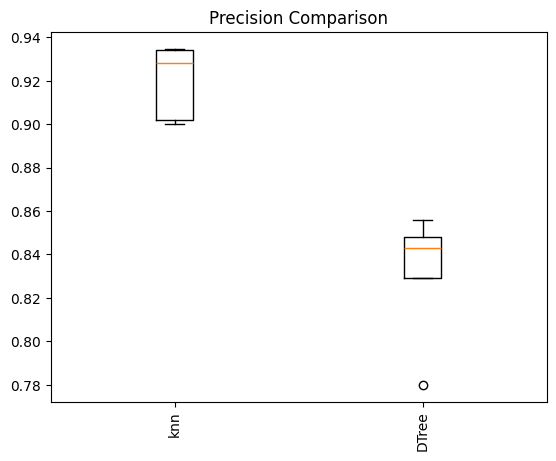

In [16]:
pre_comp = []
pre_comp.append(Knn_precision)
pre_comp.append(Dtree_precision)

fig, ax2 = plt.pyplot.subplots()
ax2.set_title('Precision Comparison')
ax2.boxplot(pre_comp)
ax2.set_xticklabels(['knn', 'DTree'], rotation='vertical')

[Text(1, 0, 'knn'), Text(2, 0, 'DTree')]

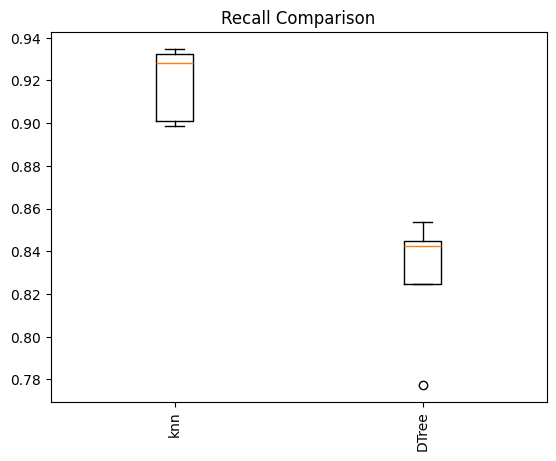

In [17]:
model_comp = []
model_comp.append(Knn_recall)
model_comp.append(Dtree_recall)

fig, ax2 = plt.pyplot.subplots()
ax2.set_title('Recall Comparison')
ax2.boxplot(model_comp)
ax2.set_xticklabels(['knn', 'DTree'], rotation='vertical')

[Text(1, 0, 'knn'), Text(2, 0, 'DTree')]

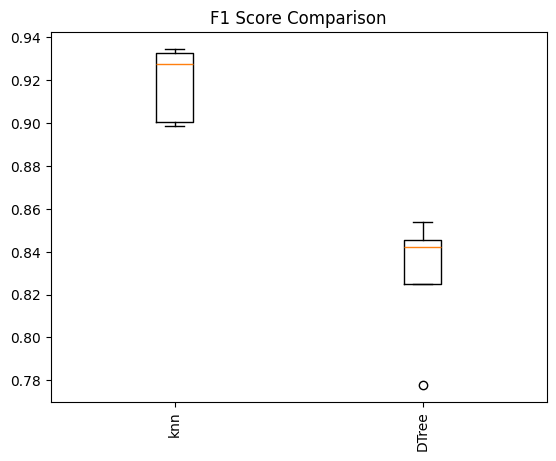

In [18]:
model_comp = []
model_comp.append(Knn_f1)
model_comp.append(Dtree_f1)

fig, ax2 = plt.pyplot.subplots()
ax2.set_title('F1 Score Comparison')
ax2.boxplot(model_comp)
ax2.set_xticklabels(['knn', 'DTree'], rotation='vertical')

For the evaluation I took the scores (Accuracy score, precision score, recall Score, F1 score) I got from running the algorithms and then put them into a box plot to visualize how they would look. From these results we can see that the k-Nearest Neighbour algorithm is outperforming the decision tree algorithm in Accuracy score, precision score, recall Score and the F1 score by about 10%.This means that Knn is the better choice for this task. For the decision tree there wasn’t much difference between the scores. While for k-Nearest Neighbour the recall was slightly higher meaning the k-Nearest Neighbour was having a higher number of true positives in relation to everything positive or in this case every article that was assigned to the right category.